In [1]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import matplotlib as mpl
import pandas as pd
import torch
import json
import sys
import os
from glob import glob
import h5py
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['font.size'] = 9


from sample_factory.utils.utils import log

In [2]:
rootpath = "/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalReward060/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "01_InternalReward01_see_22/"
# experiment_name = "02_InternalReward01_see_333/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "00_InternalReward01_see_11/"
# experiment_name = "00_InternalReward04_see_11/"
# experiment_name = "01_InternalReward04_see_22/"
# experiment_name = "02_InternalReward04_see_333/"
# experiment_name = "03_InternalReward04_see_4444/"
# experiment_name = "04_InternalReward04_see_55555/"
experiment_name = "00_InternalReward06_see_12/"
# experiment_name = "01_InternalReward06_see_23/"
# experiment_name = "02_InternalReward06_see_34/"
# experiment_name = "03_InternalReward06_see_45/"
telemetry_list_csv = glob(str(rootpath + experiment_name + "telemetry/*.csv"))
telemetry_list_h5 = glob(str(rootpath + experiment_name + "telemetry/*.h5"))
print(telemetry_list_csv)

['/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalReward060/00_InternalReward06_see_12/telemetry/pose_20251024_142012.csv']


In [3]:
pddata = pd.read_csv(telemetry_list_csv[0])
with h5py.File(telemetry_list_h5[0]) as h5:
    activations = {k: h5[k][...] for k in h5}

In [4]:
pddata

,frame,agent,x,y,z,rot_x,rot_y,rot_z,num_traj,info
0,0,0,772.093750,1841.382080,25.125,0.0,-30.388184,0.0,0,"{""num_frames"": 8}"
1,1,0,809.464905,1819.883911,25.125,0.0,-47.285156,0.0,0,"{""num_frames"": 8}"
2,2,0,841.413940,1791.223267,25.125,0.0,-64.176636,0.0,0,"{""num_frames"": 8}"
3,3,0,864.860107,1755.878906,25.125,0.0,-81.073608,0.0,0,"{""num_frames"": 8}"
4,4,0,878.048645,1714.280884,25.125,0.0,-97.970581,0.0,0,"{""num_frames"": 8}"
...,...,...,...,...,...,...,...,...,...,...
49996,49996,0,304.202942,381.227631,25.125,0.0,-25.878296,0.0,60,"{""num_frames"": 8}"
49997,49997,0,346.621185,369.396820,25.125,0.0,-42.775269,0.0,60,"{""num_frames"": 8}"
49998,49998,0,382.613007,346.028076,25.125,0.0,-59.666748,0.0,60,"{""num_frames"": 8}"
49999,49999,0,410.115021,313.182098,25.125,0.0,-76.563721,0.0,60,"{""num_frames"": 8}"


In [5]:
encoder_output = activations['encoder.DG_projection.linear']
encoder_output.shape

(50001, 16)

In [6]:
encoder_output_centered = encoder_output - encoder_output.mean(axis=0, keepdims=True)
encoder_output_centered

array([[-0.08809307, -0.20078537, -0.11402833, ...,  0.02223955,
        -0.01534887,  0.0154027 ],
       [ 0.02183473, -0.0792118 ,  0.01489988, ..., -0.06958528,
        -0.05722471, -0.04170331],
       [-0.09241381, -0.09947482, -0.07209834, ..., -0.04427013,
        -0.05124111, -0.07820669],
       ...,
       [-0.10175183, -0.13927415, -0.07662553, ...,  0.05795588,
         0.07960975,  0.05220047],
       [ 0.01644942, -0.02419165,  0.04860324, ..., -0.03379723,
         0.02033351, -0.17312422],
       [-0.00874991,  0.07471198, -0.11037737, ..., -0.01442949,
         0.09929906,  0.03938857]], dtype=float32)

In [7]:
encoder_output_centered

array([[-0.08809307, -0.20078537, -0.11402833, ...,  0.02223955,
        -0.01534887,  0.0154027 ],
       [ 0.02183473, -0.0792118 ,  0.01489988, ..., -0.06958528,
        -0.05722471, -0.04170331],
       [-0.09241381, -0.09947482, -0.07209834, ..., -0.04427013,
        -0.05124111, -0.07820669],
       ...,
       [-0.10175183, -0.13927415, -0.07662553, ...,  0.05795588,
         0.07960975,  0.05220047],
       [ 0.01644942, -0.02419165,  0.04860324, ..., -0.03379723,
         0.02033351, -0.17312422],
       [-0.00874991,  0.07471198, -0.11037737, ..., -0.01442949,
         0.09929906,  0.03938857]], dtype=float32)

In [8]:
hippo_n_feature = 16
length = 71

In [9]:
tmp_act=activations
sids=tmp_act['core'][:,:-13:length]


xbound=(100,2000)
ybound=(100,2000)
grain = 19
occu_xy=np.histogramdd((pddata['x'],
                         pddata['y']),
                         (np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),
                         density=False)[0]




grain=19
seq0_xya=np.zeros((grain,grain,hippo_n_feature))
for i in range(hippo_n_feature):
    print(i)
    seq0_xya[:,:,i]=np.histogramdd((pddata['x'],
                                      pddata['y']),
                                      (np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),
                                      weights=sids[:,i],
                                      density=False)[0]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


In [10]:
# correlation of PFs between enjoys for each layer
corr = pd.DataFrame(seq0_xya.reshape(-1,16)).corr()

/tmp/ipykernel_429354/3595453396.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0,0,0.94,1],pad=0.15)  # leave space on the right for the colorbar


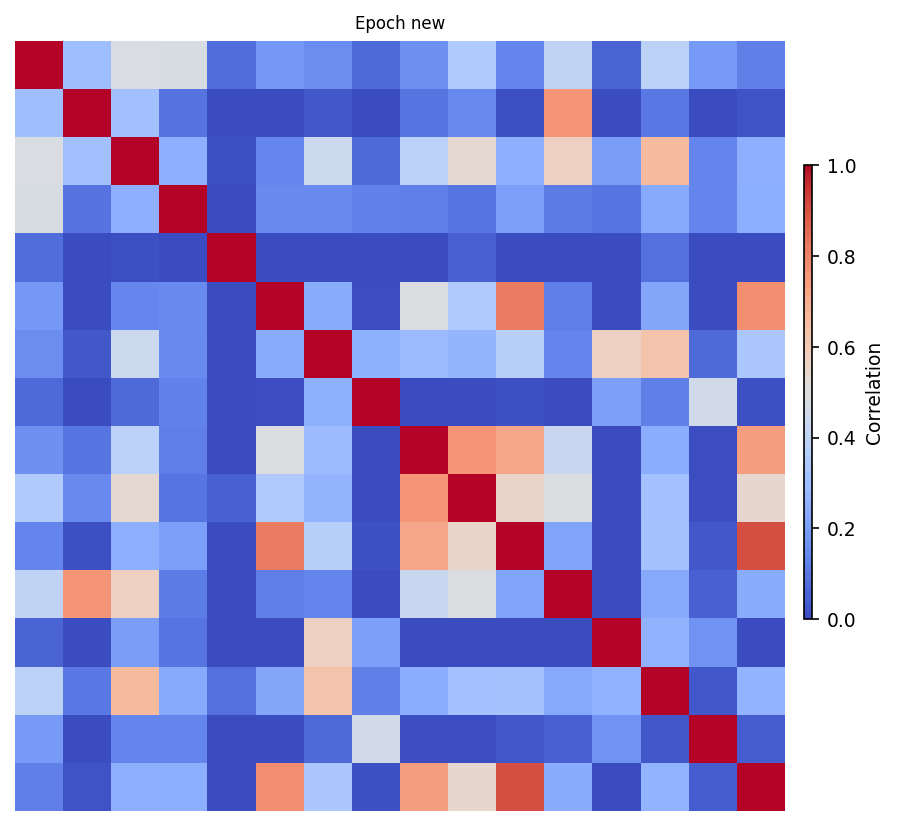

In [11]:
fig,ax=plt.subplots(1,1,figsize=(5.5, 5.5), dpi=150)
im=ax.imshow(corr,cmap='coolwarm',vmax=1,vmin=0)
ax.set_axis_off()
ax.set_title(f"Epoch {i if i<7 else 'new'}",fontsize=8)
# Label just one of them (optional)
ax.set_xlabel('DG feature index')
ax.set_ylabel('DG feature index')

# --- add a single colorbar on the right ---
# 1) create a new axes to the right of all subplots
cbar_ax = fig.add_axes([0.96, 0.25, 0.01, 0.55])  
#    [left, bottom, width, height] in fractions of figure size

# 2) draw the colorbar based on the last 'im' (they’re all the same scale)
fig.colorbar(im, cax=cbar_ax, label='Correlation')

# tidy up and save
fig.tight_layout(rect=[0,0,0.94,1],pad=0.15)  # leave space on the right for the colorbar

In [13]:
def participation_ratio(C):
    """Compute the participation ratio of an NxN correlation (or covariance) matrix."""
    eigvals = np.linalg.eigvalsh(C)  # use eigvalsh for symmetric matrices
    return (np.sum(eigvals)**2) / np.sum(eigvals**2)

In [14]:
participation_ratio(corr)

6.683986731523094